In [1]:
!pip3 install open_clip_torch -q

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import os
import glob
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import open_clip

device = torch.device("cpu")
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

In [ ]:
data_dir = "./data/confirmed_fronts"
MAX_PER_CLASS = 500

# все jpg и извлекаем цвет из имени файла (4-е поле через $$)
all_files = glob.glob(os.path.join(data_dir, "**", "*.jpg"), recursive=True)
print(f"Всего файлов: {len(all_files)}")

samples_by_color = {}
for path in all_files:
    parts = os.path.basename(path).split("$$")
    if len(parts) >= 4:
        color = parts[3]
        if color not in ("Unlisted", ""):
            samples_by_color.setdefault(color, []).append(path)

# отбираю классы с нормальным кол-во изображений 
color_counts = {c: len(v) for c, v in samples_by_color.items()}
valid_colors = sorted([c for c, n in color_counts.items() if n >= 50])
print(f"\nВсе цвета: {color_counts}")
print(f"\nВалидные классы (>= 50): {valid_colors}")

class_to_idx = {c: i for i, c in enumerate(valid_colors)}
num_classes = len(valid_colors)
class_names = valid_colors

samples = []  # (path, label)
for color in valid_colors:
    paths = samples_by_color[color]
    if len(paths) > MAX_PER_CLASS:
        paths = random.sample(paths, MAX_PER_CLASS)
    for p in paths:
        samples.append((p, class_to_idx[color]))

random.shuffle(samples)
targets = [s[1] for s in samples]
train_idx, val_idx = train_test_split(
    range(len(samples)), test_size=0.2, stratify=targets, random_state=42
)

print(f"\nКлассы ({num_classes}): {class_names}")
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}")


class CarColorDataset(Dataset):
    def __init__(self, samples, indices, transform=None):
        self.samples = samples
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        path, label = self.samples[self.indices[idx]]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = CarColorDataset(samples, train_idx, train_tfm)
val_ds = CarColorDataset(samples, val_idx, val_tfm)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

Всего файлов: 61827

Все цвета: {'Black': 14317, 'Grey': 9474, 'Red': 6095, 'Silver': 7770, 'White': 9395, 'Beige': 600, 'Blue': 8483, 'Brown': 911, 'Yellow': 667, 'Purple': 362, 'Gold': 217, 'Green': 777, 'Orange': 559, 'Multicolour': 196, 'Bronze': 329, 'Maroon': 26, 'Indigo': 1, 'Magenta': 9, 'Pink': 87, 'Burgundy': 9, 'Turquoise': 26, 'Navy': 1}

Валидные классы (>= 50): ['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Gold', 'Green', 'Grey', 'Multicolour', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'White', 'Yellow']

Классы (16): ['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Gold', 'Green', 'Grey', 'Multicolour', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'White', 'Yellow']
Train: 5352, Val: 1339


In [4]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    model.to(device)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in tqdm(range(epochs), desc="Training"):
        model.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += images.size(0)

        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out = model(images)
                loss = criterion(out, labels)
                v_loss += loss.item() * images.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total += images.size(0)

        history["val_loss"].append(v_loss / v_total)
        history["val_acc"].append(v_correct / v_total)
        
        print(f"  Epoch {epoch+1}: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

    return history


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            out = model(images)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

In [5]:
print("=" * 50)
print("Модель 1: ResNet18 (pretrained ImageNet)")
print("=" * 50)

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

for param in resnet.parameters():
    param.requires_grad = False
for param in resnet.fc.parameters():
    param.requires_grad = True
for param in resnet.layer4.parameters():
    param.requires_grad = True

h_resnet = train_model(resnet, train_loader, val_loader, epochs=5, lr=1e-3)

Модель 1: ResNet18 (pretrained ImageNet)


Training:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1: train_acc=0.5788, val_acc=0.6251
  Epoch 2: train_acc=0.7050, val_acc=0.6565
  Epoch 3: train_acc=0.7732, val_acc=0.6714
  Epoch 4: train_acc=0.8266, val_acc=0.6804
  Epoch 5: train_acc=0.8599, val_acc=0.6819


In [6]:
print("=" * 50)
print("Модель 2: CLIP ViT-B/32 (pretrained LAION-2B)")
print("=" * 50)

clip_model, _, _ = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k'
)

clip_train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.48145466, 0.4578275, 0.40821073],
                         [0.26862954, 0.26130258, 0.27577711])
])
clip_val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.48145466, 0.4578275, 0.40821073],
                         [0.26862954, 0.26130258, 0.27577711])
])

clip_train_ds = CarColorDataset(samples, train_idx, clip_train_tfm)
clip_val_ds = CarColorDataset(samples, val_idx, clip_val_tfm)
clip_train_loader = DataLoader(clip_train_ds, batch_size=32, shuffle=True, num_workers=0)
clip_val_loader = DataLoader(clip_val_ds, batch_size=32, shuffle=False, num_workers=0)


class CLIPClassifier(nn.Module):
    def __init__(self, clip_visual, num_classes, embed_dim=512):
        super().__init__()
        self.visual = clip_visual
        for p in self.visual.parameters():
            p.requires_grad = False
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            features = self.visual(x)
        return self.head(features)


clip_clf = CLIPClassifier(clip_model.visual, num_classes)
h_clip = train_model(clip_clf, clip_train_loader, clip_val_loader, epochs=5, lr=1e-3)

Модель 2: CLIP ViT-B/32 (pretrained LAION-2B)


Training:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1: train_acc=0.3337, val_acc=0.4533
  Epoch 2: train_acc=0.5133, val_acc=0.5400
  Epoch 3: train_acc=0.5917, val_acc=0.5765
  Epoch 4: train_acc=0.6297, val_acc=0.5810
  Epoch 5: train_acc=0.6541, val_acc=0.6079


In [ ]:
print("=" * 50)
print("Модель 3: Custom CNN (с нуля)")
print("=" * 50)


class CustomCNN(nn.Module):
    """
    Обоснование архитектуры:
    4 свёрточных блока (Conv2d + BatchNorm + ReLU + MaxPool)-структура с увеличением числа фильтров (32 -> 64 -> 128 -> 256)
    BatchNorm после каждой свёртки  ускоряет сходимость и стабилизирует обучение
    AdaptiveAvgPool глобальный пулинг вместо Flatten, что уменьшает число параметров и делает модель устойчивой к разным размерам входа
    Dropout(0.3) перед классификатором-регуляризация для борьбы с переобучением
    Архитектура намеренно компактная (~400K параметров vs ~11M у ResNet18) чтобы продемонстрировать разницу между обучением с нуля и transfer learning)
    """

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


custom_cnn = CustomCNN(num_classes)
total_params = sum(p.numel() for p in custom_cnn.parameters())
print(f"Параметров в Custom CNN: {total_params:,}")
h_custom = train_model(custom_cnn, train_loader, val_loader, epochs=8, lr=1e-3)

Модель 3: Custom CNN (с нуля)
Параметров в Custom CNN: 393,488


Training:   0%|          | 0/8 [00:00<?, ?it/s]

  Epoch 1: train_acc=0.3492, val_acc=0.4309
  Epoch 2: train_acc=0.4223, val_acc=0.3846
  Epoch 3: train_acc=0.4531, val_acc=0.4100
  Epoch 4: train_acc=0.4583, val_acc=0.4862
  Epoch 5: train_acc=0.4824, val_acc=0.5108
  Epoch 6: train_acc=0.4916, val_acc=0.4907
  Epoch 7: train_acc=0.5093, val_acc=0.5034
  Epoch 8: train_acc=0.5071, val_acc=0.5108


In [8]:
results = {}

for name, model, loader in [
    ("ResNet18 (ImageNet)", resnet, val_loader),
    ("CLIP ViT-B/32 (LAION-2B)", clip_clf, clip_val_loader),
    ("Custom CNN", custom_cnn, val_loader),
]:
    preds, labels = get_predictions(model, loader)
    f1 = f1_score(labels, preds, average="macro")
    results[name] = f1
    print(f"\n{name}:")
    print(f"  F1_macro = {f1:.4f}")
    print(classification_report(labels, preds, target_names=class_names))


ResNet18 (ImageNet):
  F1_macro = 0.6736
              precision    recall  f1-score   support

       Beige       0.81      0.55      0.65       100
       Black       0.41      0.86      0.55       100
        Blue       0.65      0.68      0.67       100
      Bronze       0.57      0.45      0.50        66
       Brown       0.52      0.47      0.49       100
        Gold       0.49      0.59      0.54        44
       Green       0.84      0.75      0.79       100
        Grey       0.59      0.34      0.43       100
 Multicolour       0.59      0.33      0.43        39
      Orange       0.74      0.93      0.82       100
        Pink       0.88      0.88      0.88        17
      Purple       0.75      0.68      0.71        73
         Red       0.93      0.75      0.83       100
      Silver       0.66      0.73      0.70       100
       White       0.84      0.85      0.85       100
      Yellow       0.98      0.88      0.93       100

    accuracy                          

/Users/kirilllesniak/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kirilllesniak/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kirilllesniak/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

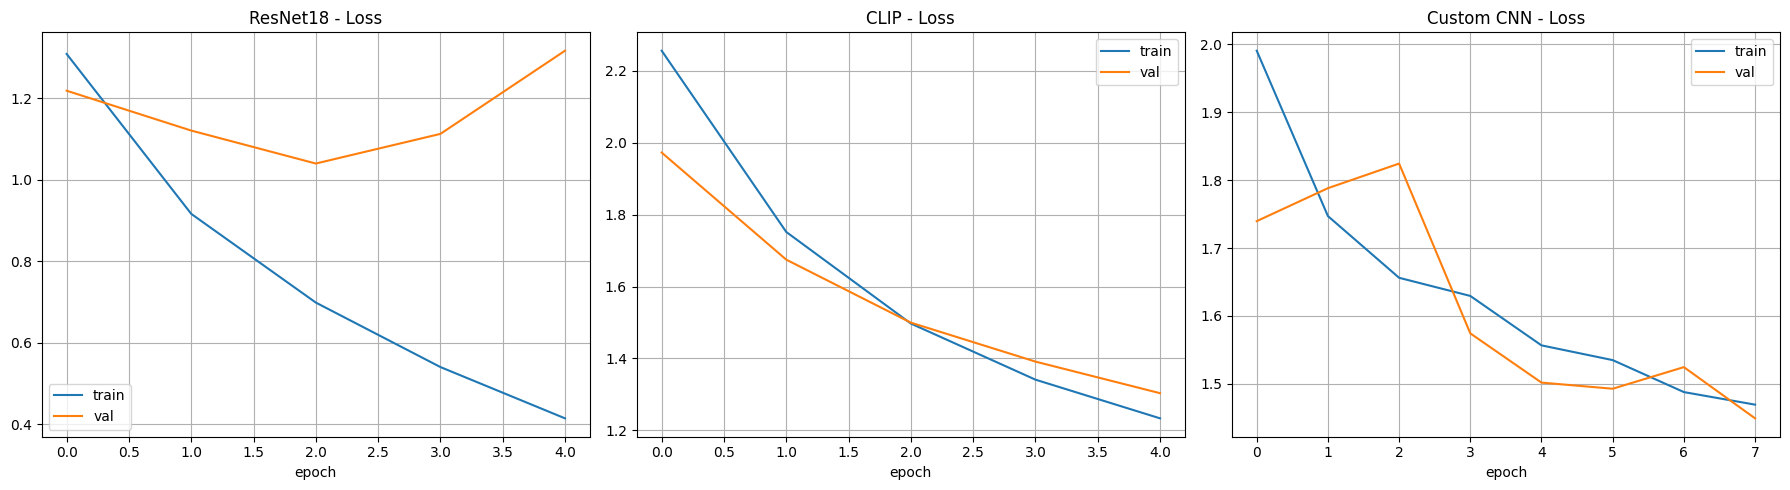

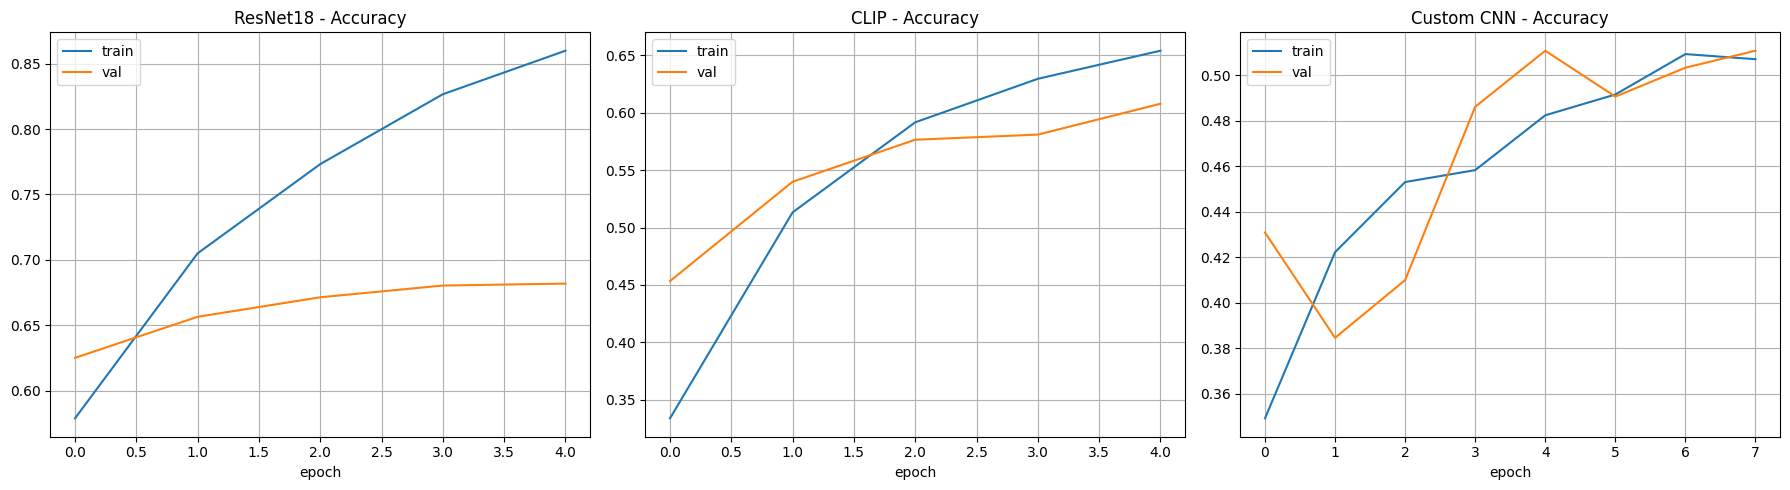

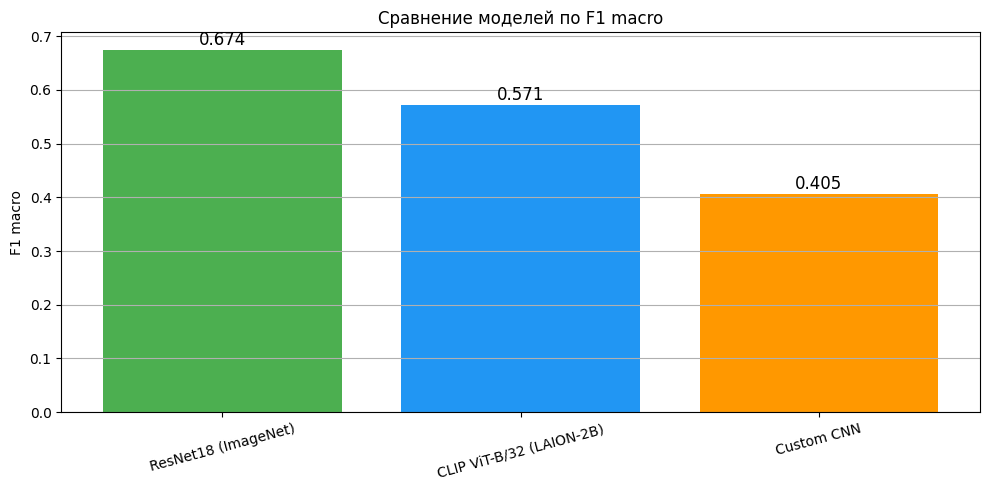

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, h) in zip(axes, [
    ("ResNet18", h_resnet), ("CLIP", h_clip), ("Custom CNN", h_custom)
]):
    ax.plot(h["train_loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_title(f"{name} - Loss")
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, h) in zip(axes, [
    ("ResNet18", h_resnet), ("CLIP", h_clip), ("Custom CNN", h_custom)
]):
    ax.plot(h["train_acc"], label="train")
    ax.plot(h["val_acc"], label="val")
    ax.set_title(f"{name} - Accuracy")
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

names = list(results.keys())
scores = list(results.values())
plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(names)), scores, color=["#4CAF50", "#2196F3", "#FF9800"])
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{score:.3f}", ha="center", fontsize=12)
plt.xticks(range(len(names)), names, rotation=15)
plt.ylabel("F1 macro")
plt.title("Сравнение моделей по F1 macro")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [10]:
import json

output = {
    "dataset": "DVM-CAR confirmed_fronts (color classification)",
    "num_classes": num_classes,
    "classes": class_names,
    "train_size": len(train_idx),
    "val_size": len(val_idx),
    "models": {}
}

for name, h in [("ResNet18 (ImageNet)", h_resnet), ("CLIP ViT-B/32 (LAION-2B)", h_clip), ("Custom CNN", h_custom)]:
    output["models"][name] = {
        "f1_macro": round(results[name], 4),
        "final_train_acc": round(h["train_acc"][-1], 4),
        "final_val_acc": round(h["val_acc"][-1], 4),
    }

with open("results.json", "w") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(json.dumps(output, indent=2, ensure_ascii=False))

{
  "dataset": "DVM-CAR confirmed_fronts (color classification)",
  "num_classes": 16,
  "classes": [
    "Beige",
    "Black",
    "Blue",
    "Bronze",
    "Brown",
    "Gold",
    "Green",
    "Grey",
    "Multicolour",
    "Orange",
    "Pink",
    "Purple",
    "Red",
    "Silver",
    "White",
    "Yellow"
  ],
  "train_size": 5352,
  "val_size": 1339,
  "models": {
    "ResNet18 (ImageNet)": {
      "f1_macro": 0.6736,
      "final_train_acc": 0.8599,
      "final_val_acc": 0.6819
    },
    "CLIP ViT-B/32 (LAION-2B)": {
      "f1_macro": 0.5714,
      "final_train_acc": 0.6541,
      "final_val_acc": 0.6079
    },
    "Custom CNN": {
      "f1_macro": 0.4055,
      "final_train_acc": 0.5071,
      "final_val_acc": 0.5108
    }
  }
}
